# **Author: Mukhamedali Daniyaruly**
# **Date: 30/04/2026**
# **Topic: Qwen3.5 fine tuning on Math dataset**

In [ ]:
!pip install -U bitsandbytes

In [ ]:
!pip install --upgrade transformers evaluate

In [ ]:
import wandb

import re
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image
from datasets import load_dataset
from dataclasses import dataclass
import evaluate

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from typing import Any, Dict, List, Tuple
from peft import get_peft_model, LoraConfig
from transformers import AutoModel, AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig, TrainingArguments, Trainer

In [ ]:
@dataclass
class Configuration:
  def __init__(self):
    self.model_id = "Qwen/Qwen3.5-0.8b"
    self.learning_rate = 2e-5
    self.gradient_accumulation_steps=8
    self.epochs = 1
    self.r = 16
    self.alpha_rank = 32
    self.max_length=1024
    self.logging_steps=10

config = Configuration()

# **Download a model and tokenizer**

In [ ]:
# Bits And Bytes: to reduce the memory of our hardware
bits_and_bytes_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_double_compute=True,
    bnb_4bit_compute_type=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
# Lora Configuration: We add trainable parameters
lora_config = LoraConfig(
    r=config.r,
    lora_alpha=config.alpha_rank,
    lora_dropout=0.01,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
)

In [ ]:
# Download Qwen model
model = AutoModelForImageTextToText.from_pretrained(config.model_id, quantization_config=bits_and_bytes_config)
processor = AutoProcessor.from_pretrained(config.model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [ ]:
# Get lora model
lora_model = get_peft_model(model, lora_config)
processor.tokenizer.eos_token_id = processor.tokenizer.pad_token_id
processor.tokenizer.padding_side = "left"

# Download other models

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-0.6B")
messages = [
    {"role": "user", "content": "Who are you?"},
]
inputs = tokenizer.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
print(tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:]))

# **Download a dataset and prepare**

In [ ]:
# Download dataset
train_ds = load_dataset("TIGER-Lab/VisualWebInstruct-Seed", "LongCoT", split="train[:500]")
val_ds = load_dataset("TIGER-Lab/VisualWebInstruct-Seed", "LongCoT", split="train[500:575]")
test_ds = load_dataset("TIGER-Lab/VisualWebInstruct-Seed", "LongCoT", split="train[575:650]")

# **Sample of dataset**

In this part we visualize and see samples.

In [ ]:
# Function to plot samples
def plot_sample(sample):
  image = sample["image"]
  question = sample["question"]
  answer = sample["answer"]

  print(f"Question: {question}")
  print(f"Answer: {answer}")

  plt.imshow(image)
  plt.axis("off")
  plt.show()

# **Dataset preparing**

We prepare image + text sample. Also we add an additional prompt and pass this sample to the model.

In [ ]:
# Preparing Chain-of-Thougts function
def prepare_cot_dataset(row):
  prompt = row["question"] + "\n\nThink step-by-step. Put your final exact answer inside <answer> and </answer> tags."
  assistant_target = f"{row["long_answer"]}\n\n<answer>{row["short_answer"]}</answer>."

  messages = [
      {
          "role": "user",
          "content": [
              {"type": "image"},
              {"type": "text", "text": prompt}
          ]
      },
      {
          "role": "assistant",
          "content": [
              {"type": "text", "text": assistant_target}
          ]
      }
  ]

  return messages

In [ ]:
class VLMdataset(Dataset):
  def __init__(self, dataset, processor, max_length):
    self.dataset=dataset
    self.processor = processor
    self.max_length = max_length

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    sample = self.dataset[idx]
    image = sample["image"]
    messages = prepare_cot_dataset(sample)


    text_prompt = self.processor.apply_chat_template(messages, add_generation_prompt=True)

    return {
        "text_prompt": text_prompt,
        "image": image
    }

In [ ]:
@dataclass
class DataCollator:
  processor: Any

  def __call__(self, instances: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
    texts = [instance["text_prompt"] for instance in instances]
    image = [instance["image"] for instance in instances]

    batch = self.processor(
        text=texts,
        images=image,
        padding=True,
        return_tensors="pt"
    )

    labels = batch["input_ids"].clone()

    if self.processor.tokenizer.pad_token is not None:
      labels[labels == self.processor.tokenizer.pad_token_id] = -100

    batch["labels"] = labels

    return batch

In [ ]:
# Prepare Data Collator
data_collator = DataCollator(processor=processor)

# Create training, validation and testing data classes
train_dataset = VLMdataset(train_ds, processor, max_length=config.max_length)
val_dataset = VLMdataset(val_ds, processor, max_length=config.max_length)
test_dataset = VLMdataset(test_ds, processor, max_length=config.max_length)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=2, collate_fn=data_collator)
val_loader = DataLoader(val_dataset, batch_size=2, collate_fn=data_collator)
test_loader = DataLoader(test_dataset, batch_size=2, collate_fn=data_collator)

# Functions to compute metrics


In [ ]:
# Pre-compile regex for performance across large evaluation batches
THINK_PATTERN = re.compile(r"<think>(.*?)</think>", re.DOTALL)
ANSWER_PATTERN = re.compile(r"<answer>(.*?)</answer>", re.DOTALL | re.IGNORECASE)


def clean_math_string(s: str) -> str:
    """Standardizes math strings for more robust comparison."""
    if not s:
        return ""
    # Remove spaces, lowercase, remove common LaTeX wrappers if present
    s = s.replace(" ", "").lower()
    # BUG FIX 1: misplaced closing quote caused a SyntaxError
    s = s.replace("\\(", "").replace("\\)", "")
    s = s.replace("$", "")
    return s.strip()


def parse_generation(text: str) -> Tuple[str, str]:
    """Extracts the reasoning block and the final answer from the model output."""
    think_match = THINK_PATTERN.search(text)
    answer_match = ANSWER_PATTERN.search(text)

    think_content = think_match.group(1).strip() if think_match else ""
    final_answer = answer_match.group(1).strip() if answer_match else ""

    return think_content, final_answer


def score_single_prediction(
    pred_text: str,
    true_answer: str,
    max_optimal_length: int = 600
) -> Dict[str, float]:
    """
    Computes the granular score for a single model generation.

    Scoring rules:
    - 0.5 points for successfully using <think>...</think> tags with actual content.
    - 0.5 points for the exact correct final answer.
    - +0.1 points if the answer is correct AND the total output length is efficient
      (< max_optimal_length chars).
    - -0.2 penalty if <think> tag is left unclosed OR no final answer was produced.
    Score is capped between 0.0 and 1.1.
    """
    score = 0.0
    metrics = {
        "score": 0.0,
        "has_think": 0.0,
        "is_correct": 0.0,
        "efficiency_bonus": 0.0,
        "format_penalty": 0.0,
    }

    think_content, extracted_answer = parse_generation(pred_text)

    # 1. Evaluate reasoning tags (+0.5)
    #    Require at least 10 characters of actual reasoning inside the block.
    if len(think_content) > 10:
        score += 0.5
        metrics["has_think"] = 1.0

    # 2. Evaluate correctness (+0.5)
    clean_pred = clean_math_string(extracted_answer)
    clean_truth = clean_math_string(true_answer)

    # BUG FIX 2: variable was named clean_true but defined as clean_truth
    is_correct = (clean_pred == clean_truth) and (clean_truth != "")
    if is_correct:
        score += 0.5
        metrics["is_correct"] = 1.0

    # 3. Efficiency bonus (+0.1)
    #    Only awarded when the model was also correct.
    if is_correct and len(pred_text) < max_optimal_length:
        # BUG FIX 3: `score += 0.1,` created a tuple; must be a plain float addition
        score += 0.1
        metrics["efficiency_bonus"] = 0.1

    # 4. Format penalty (-0.2)
    #    Penalise an unclosed <think> tag OR a missing final answer line.
    has_unclosed_think = "<think>" in pred_text and "</think>" not in pred_text
    has_no_answer = extracted_answer == ""
    if has_unclosed_think or has_no_answer:
        score -= 0.2
        metrics["format_penalty"] = -0.2

    # 5. Cap score between 0.0 and 1.1
    # BUG FIX 4: cap was described in the docstring but never actually applied
    score = max(0.0, min(1.1, score))

    # BUG FIX 5: metrics["score"] was initialised to 0.0 and never updated
    metrics["score"] = score

    return metrics


def build_compute_metrics_fn(processor, max_optimal_length: int = 600):
    """
    Returns a compute_metrics function compatible with the HuggingFace Trainer.
    """
    def compute_metrics(eval_preds) -> Dict[str, float]:
        # BUG FIX 6: eval_preds was never unpacked — preds and labels were undefined
        preds, labels = eval_preds

        # Replace -100 padding tokens so the tokenizer can decode them
        # BUG FIX 7: labels = np.where(labels != -100, labels, ...) referenced
        #             labels before the line was evaluated — works fine once unpacked above
        labels = np.where(labels != -100, labels, processor.tokenizer.pad_token_id)

        decoded_preds  = processor.tokenizer.batch_decode(preds,  skip_special_tokens=True)
        decoded_labels = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)

        total_metrics = {
            "eval_score": 0.0,
            # BUG FIX 8: "compilance" was a typo; corrected to "compliance"
            "eval_think_compliance": 0.0,
            "eval_accuracy": 0.0,
            "eval_efficiency_bonus": 0.0,
        }

        # BUG FIX 9: num_samples was computed inside the loop, re-assigning on
        #             every iteration. Moved outside so the final division is correct.
        num_samples = len(decoded_preds)
        if num_samples == 0:
            return total_metrics

        for pred, label in zip(decoded_preds, decoded_labels):
            _, true_answer = parse_generation(label)

            # Fallback: if the label wasn't wrapped in the standard format,
            # treat the raw label string as the ground-truth answer.
            if not true_answer:
                true_answer = (
                    label.split("Final Answer:")[-1].strip()
                    if "Final Answer:" in label
                    else label
                )

            scores = score_single_prediction(pred, true_answer, max_optimal_length)

            total_metrics["eval_score"]            += scores["score"]
            total_metrics["eval_think_compliance"] += scores["has_think"]
            total_metrics["eval_accuracy"]         += scores["is_correct"]
            total_metrics["eval_efficiency_bonus"] += scores["efficiency_bonus"]

        return {k: v / num_samples for k, v in total_metrics.items()}

    return compute_metrics

# **Baseline model check before training**

In [ ]:
THINK_PATTERN = re.compile(r"<think>(.*?)</think>", re.DOTALL)
ANSWER_PATTERN = re.compile(r"<answer>(.*?)</answer>", re.DOTALL | re.IGNORECASE)

def clean_math_string(s: str) -> str:
    if not s:
        return ""
    s = s.replace(" ", "").lower()
    s = s.replace("\\(", "").replace("\\)", "")
    s = s.replace("$", "")
    return s.strip()

def parse_generation(text: str) -> Tuple[str, str]:
    think_match  = THINK_PATTERN.search(text)
    answer_match = ANSWER_PATTERN.search(text)
    think_content = think_match.group(1).strip()  if think_match  else ""
    final_answer  = answer_match.group(1).strip() if answer_match else ""
    return think_content, final_answer

def score_single_prediction(pred_text: str, true_answer: str) -> Dict[str, float]:
    score = 0.0
    metrics = {
        "score": 0.0, "has_think": 0.0, "is_correct": 0.0,
        "efficiency_bonus": 0.0, "format_penalty": 0.0,
    }

    think_content, extracted_answer = parse_generation(pred_text)

    # 1. Reasoning перед ответом (+0.5)
    text_before_answer = pred_text.split("<answer>")[0] if "<answer>" in pred_text else ""
    has_reasoning = len(text_before_answer.strip()) > 50
    if has_reasoning:
        score += 0.5
        metrics["has_think"] = 1.0

    # 2. Правильность ответа (+0.5)
    clean_pred  = clean_math_string(extracted_answer)
    clean_truth = clean_math_string(true_answer)
    is_correct  = (clean_pred == clean_truth) and (clean_truth != "")
    if is_correct:
        score += 0.5
        metrics["is_correct"] = 1.0

    # 3. Бонус за краткость (+0.1)
    if is_correct and len(pred_text) < 600:
        score += 0.1
        metrics["efficiency_bonus"] = 0.1

    # 4. Штраф за отсутствие тега <answer> (-0.2)
    if "<answer>" not in pred_text or "</answer>" not in pred_text:
        score -= 0.2
        metrics["format_penalty"] = -0.2

    metrics["score"] = round(max(0.0, min(1.1, score)), 4)
    return metrics

def compute_loss_only(model, loader, loss_batches=30):
    total_loss = 0.0
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc="Loss")):
            if i >= loss_batches:
                break
            ins    = batch["input_ids"].to(model.device)
            attn   = batch["attention_mask"].to(model.device)
            labels = batch["labels"].to(model.device)
            outs   = model(input_ids=ins, attention_mask=attn, labels=labels)
            total_loss += outs.loss.item()
            del ins, attn, labels, outs
            torch.cuda.empty_cache()
    return round(total_loss / min(loss_batches, len(loader)), 4)

def compute_metrics_only(model, loader, processor, metric_batches=10):
    total_metrics = {
        "score": 0.0, "think_compliance": 0.0,
        "accuracy": 0.0, "efficiency_bonus": 0.0, "format_penalty": 0.0,
    }
    n = 0
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc="Metrics")):
            if i >= metric_batches:
                break

            ins    = batch["input_ids"].to(model.device)
            attn   = batch["attention_mask"].to(model.device)
            labels = batch["labels"].to(model.device)

            generated = model.generate(
                input_ids=ins,
                attention_mask=attn,
                max_new_tokens=256,
                do_sample=False,
            )

            prompt_len    = ins.shape[-1]
            decoded_preds = processor.tokenizer.batch_decode(
                generated[:, prompt_len:], skip_special_tokens=True
            )

            clean_labels = labels.clone()
            clean_labels[clean_labels == -100] = processor.tokenizer.pad_token_id
            decoded_labels = processor.tokenizer.batch_decode(
                clean_labels, skip_special_tokens=True
            )

            for pred, label in zip(decoded_preds, decoded_labels):
                # Извлекаем правильный ответ из лейбла
                _, true_answer = parse_generation(label)
                if not true_answer:
                    if "<answer>" in label:
                        true_answer = label.split("<answer>")[-1].split("</answer>")[0].strip()
                    else:
                        true_answer = label.strip()

                scores = score_single_prediction(pred, true_answer)

                total_metrics["score"]            += scores["score"]
                total_metrics["think_compliance"] += scores["has_think"]
                total_metrics["accuracy"]         += scores["is_correct"]
                total_metrics["efficiency_bonus"] += scores["efficiency_bonus"]
                total_metrics["format_penalty"]   += scores["format_penalty"]
                n += 1

            del ins, attn, labels, generated, decoded_preds, clean_labels, decoded_labels
            torch.cuda.empty_cache()

    n = max(n, 1)
    return {k: round(v / n, 4) for k, v in total_metrics.items()}

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

print("=== Before training ===")

print("\nVal loss...")
val_loss = compute_loss_only(lora_model, val_loader, loss_batches=30)
torch.cuda.empty_cache(); gc.collect()

print("\nVal metrics...")
val_metrics = compute_metrics_only(lora_model, val_loader, processor, metric_batches=10)
torch.cuda.empty_cache(); gc.collect()

print(f"\nVal loss: {val_loss}")
for k, v in val_metrics.items():
    print(f"  {k:20s}: {v}")

=== Before training ===

Val loss...


Loss:   0%|          | 0/38 [00:00<?, ?it/s]


Val metrics...


Metrics:   0%|          | 0/38 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.



Val loss: 1.311
  score               : 0.0
  think_compliance    : 0.0
  accuracy            : 0.0
  efficiency_bonus    : 0.0
  format_penalty      : -0.2


In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()
torch.cuda.empty_cache()
print(f"Free memory: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

Free memory: 20.5 GB


# **Training state**

In [ ]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: m_daniyaruly (m_daniyaruly-kbtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(
    project="Qwen3.5-VL-Math",
    name="Qwen3.5-VL-lora16",
    config={
        "architecture": "Qwen3.5-0.8b",
        "dataset": "Math-dataset",
        "lora_r": 16,
        "lora_alpha": 32,
        "learning_rate": 2e-5,
        "epochs": 1
    }
)

Training Arguments: 1. batch_size = 1. gradient_checkpointing = 2.

In [ ]:
training_arguments = TrainingArguments(
    output_dir="./qwen-vlm",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    num_train_epochs=1,
    bf16=True,
    logging_steps=10,
    optim="adamw_torch_fused",
    remove_unused_columns=False,
    gradient_checkpointing=True,
    dataloader_num_workers=2,

    eval_strategy="steps",
    eval_steps=20,
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,

    prediction_loss_only=True,
    report_to="wandb",
    run_name="Qwen3.5-VL-lora16"
)

In [ ]:
trainer = Trainer(
    model=lora_model,
    args=training_arguments,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator
)

In [ ]:
trainer.train()

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
20,2.891462,2.186333
40,2.648102,2.065320
60,2.741929,2.009230
63,2.741929,2.008661


TrainOutput(global_step=63, training_loss=2.7362901142665317, metrics={'train_runtime': 1923.3614, 'train_samples_per_second': 0.26, 'train_steps_per_second': 0.033, 'total_flos': 3010186360635648.0, 'train_loss': 2.7362901142665317, 'epoch': 1.0})

# Inference: Qwen3.5-0.8b

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


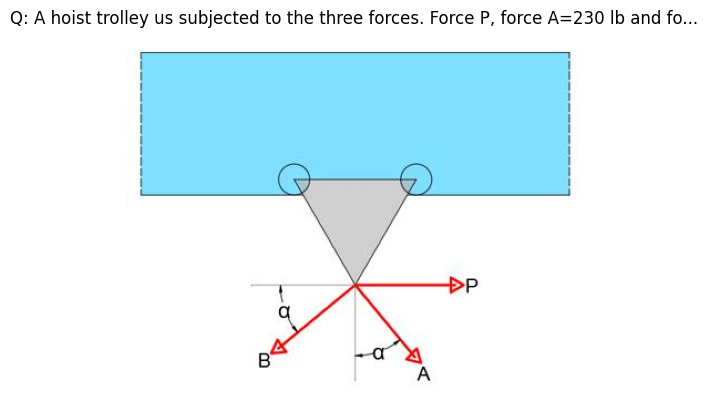


Model answer: To determine the **required magnitude** of force $P$, we need to analyze the equilibrium conditions for the system under consideration — specifically, since it's a hoist trolley subjecting to three concurrent forces (forces acting at a common point), and we’re told that the **resultant must be vertical**.

---

### Step 1: Understand the Geometry and Forces

We have three forces acting on the hoist trolley:

- Force $P$ acts horizontally (along the x-axis).
- Force $A = 230\,\text{lb}$ acts along line AB at an angle $\alpha = 40^\circ$.
- Force $B = 400\,\text{lb}$ acts along line BC at another angle $\beta = ?$ but not explicitly given directly; however, from the diagram description, points A, B, C form a triangle with angles related to α.

From standard problems involving such setups (especially those found in textbooks like Hibbeler’s *Engineering Mechanics*), when you have three forces meeting at a point and want their resultant to be vertical, there’s often a geomet

In [ ]:
def process_inference(sample, idx):
    image    = sample["image"][idx]
    question = sample["question"][idx]

    messages = [
        {"role": "system", "content": "You are a helpful AI assistant. Put the final answer in <answer> and </answer> tags"},  # ← "content" не "text"
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": question}]}
    ]

    text_prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

    inputs = processor(
        text=[text_prompt],
        images=[image],
        return_tensors="pt"
    ).to(lora_model.device)

    return inputs


def get_answer(model, inputs):
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=True,
            repetition_penalty=1.15,
            top_p=0.9,
            temperature=0.2
        )
    return processor.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)


def show_answer(model, ds, index: int = 101):
    inputs = process_inference(ds, index)
    result = get_answer(model, inputs)

    plt.imshow(ds["image"][index])
    plt.axis("off")
    plt.title(f"Q: {ds['question'][index][:80]}...")
    plt.show()

    print(f"\nModel answer: {result}")

show_answer(lora_model, train_ds, 101)

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


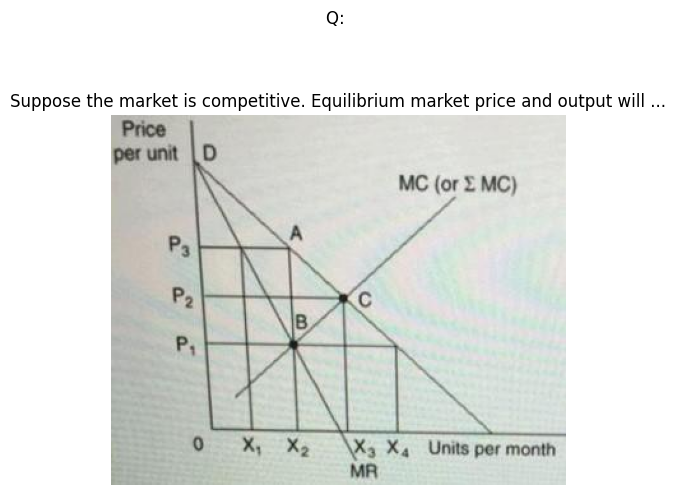


Model answer: To determine the equilibrium market conditions under both **competitive** and **monopolistic** markets, we need to analyze how each type of market determines supply and demand based on its structure.

---

### 1. **Competitive Market (Perfect Competition)**

In perfect competition:

- There are many buyers and sellers with no barriers to entry or exit.
- The **supply curve equals the demand curve**.
- At any given quantity, there’s an equal amount of producers who want more at that price vs consumers willing to buy less than they pay for.
- Therefore, **equilibrium occurs where Supply = Demand**, which corresponds to the intersection of the **MC curve and MR curve**.

From the diagram:
- In competitive equilibrium, the MC curve intersects the MR curve at point C.
- So, **Equilibrium Price = P₃**, and **Quantity = X₂**.

✅ **Answer:**  
Under competitive market → **Price = $P_3$, Quantity = X₂**

---

### 2. **Monopoly Market (Oligopolist/Market Power)**

A monopoly firm 

In [ ]:
show_answer(lora_model, train_ds, 22)

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


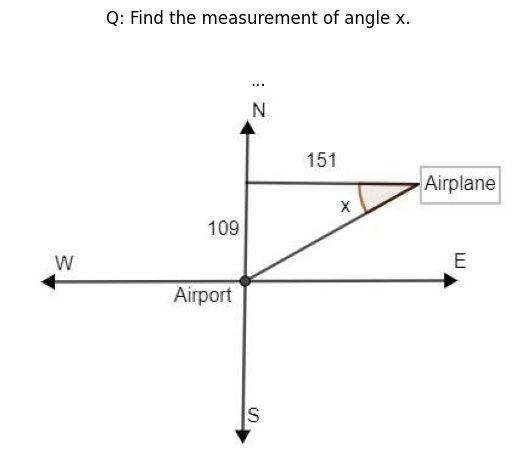


Model answer: We are given a right-angled triangle with vertices at:

- **Airport** (origin)
- A point labeled **“Airplane”** located to the **East** and **North** of the airport, forming an angle $x$ with the North-East direction.
- The hypotenuse connects these two points.
- We’re told that one leg is 151 units long along the East-West axis, and another leg is 109 units long along the South-North axis.

Let’s assign coordinates using standard Cartesian system:

---

### Step 1: Assign Coordinates

Place the **airport** at origin $(0, 0)$ for simplicity.

Since we're dealing only with directions relative to axes:

- Let’s define:
  - **West**: negative x-axis → so any movement west from airport has coordinate $(-d, 0)$
  - **South**: negative y-axis → southward movement has coordinate $(0, -h)$
  - **East**: positive x-axis → eastward movement has coordinate $(+w, 0)$
  - **North**: positive y-axis → northward movement has coordinate $(0, +n)$

Now, locate “Airplane”:

It's located *

In [ ]:
show_answer(lora_model, train_ds, 7)

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


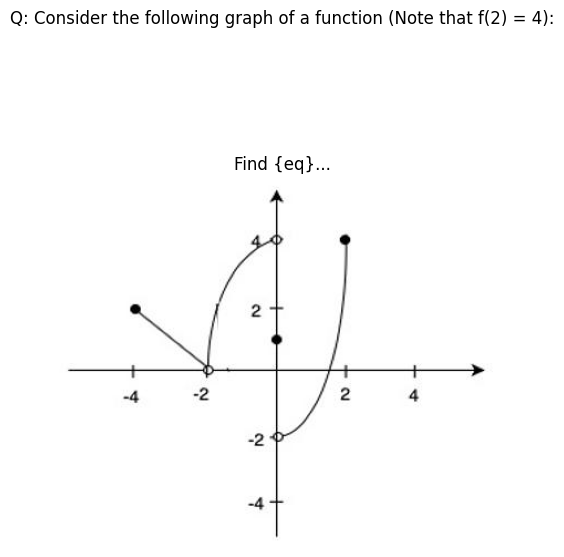


Model answer: We are given a piecewise-defined function $ f(x) $ based on its graph, with the note:  
> **$ f(2) = 4 $** — this is an important constraint to use when evaluating or finding values at specific points like $ x=0 $.

Let’s analyze the behavior of the function from left to right by examining the graph:

---

### Step 1: Understand the pieces of the function

From the graph:

- For $ -3 \leq x \leq -2 $: The function has a vertical asymptote at $ x=-2 $, but since it's open on both sides near $ (-2, 0) $, we interpret this as having no value there? Or perhaps it's just a hole? But wait — looking closely, the line goes *from* $(-2, 0)$ *to* $(?, ?)$ — actually, let me re-express what I see.

Actually, looking again:

The graph shows three segments:

1. From $x = -3$ up to $x = -2$, where the curve approaches $ y = 0 $ as $ x \to -2^- $? No — wait, let me describe coordinates more carefully.

Looking at the axes:

- At $ x = -2 $, there's a point labeled “open circle” at some

In [ ]:
show_answer(lora_model, train_ds, 19)

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


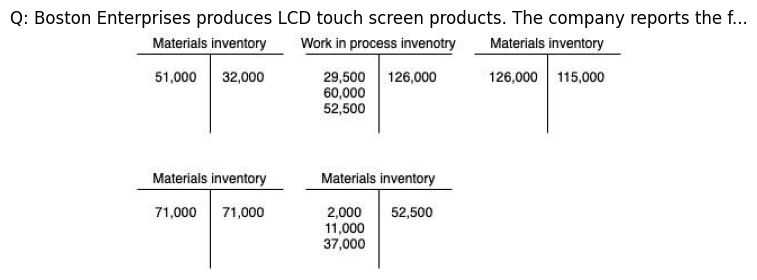


Model answer: To find the **cost of indirect labor** for Boston Enterprises, we need to follow these steps:

---

### Step 1: Understand what “indirect labor” means  
In accounting (especially under U.S. GAAP or similar frameworks), *direct labor* refers to wages paid directly to employees who perform services that can be traced back to specific jobs/tasks.  
**Indirect labor**, by contrast, includes other forms of labor — such as supervisors’ salaries, administrative staff salaries, etc., which cannot be easily assigned to individual job tasks but still contribute to production costs.

So, if you’re asked for **“the cost of indirect labor”**, it implies asking for **total indirect labor expenses**, not just one type. That would include all non-direct labor costs incurred during production.

But wait… let’s look more carefully.

Actually, looking again at the data provided:

We have four separate tables labeled with different headings like:
- Materials inventory
- Work in process inve

In [ ]:
show_answer(lora_model, train_ds, 44)

# Compute metrics after training and comparison with other models

Trained Qwen

In [ ]:
print("\nVal loss...")
val_loss = compute_loss_only(lora_model, val_loader, loss_batches=30)

print("\nVal metrics...")
val_metrics = compute_metrics_only(lora_model, val_loader, processor, metric_batches=10)

print(f"\nVal loss: {val_loss}")
for k, v in val_metrics.items():
    print(f"  {k:20s}: {v}")


Val loss...


Loss:   0%|          | 0/38 [00:00<?, ?it/s]


Val metrics...


Metrics:   0%|          | 0/38 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.



Val loss: 1.2596
  score               : 0.0
  think_compliance    : 0.0
  accuracy            : 0.0
  efficiency_bonus    : 0.0
  format_penalty      : -0.2


In [ ]:
print("\nTest loss...")
test_loss = compute_loss_only(lora_model, test_loader, loss_batches=30)

print("\nTest metrics...")
test_metrics = compute_metrics_only(lora_model, test_loader, processor, metric_batches=10)

print(f"\nTest loss: {val_loss}")
for k, v in test_metrics.items():
    print(f"  {k:20s}: {v}")


Test loss...


Loss:   0%|          | 0/38 [00:00<?, ?it/s]


Test metrics...


Metrics:   0%|          | 0/38 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.



Test loss: 1.2596
  score               : 0.025
  think_compliance    : 0.05
  accuracy            : 0.0
  efficiency_bonus    : 0.0
  format_penalty      : -0.19


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
qwen = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct",
    quantization_config=bits_and_bytes_config, device_map="auto")

smol_tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct")
smol = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-360M-Instruct",
    quantization_config=bits_and_bytes_config, device_map="auto")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
def compute_comparison_metrics(model, tokenizer, loader, metric_batches=10):
    total_metrics = {
        "score": 0.0, "think_compliance": 0.0,
        "accuracy": 0.0, "efficiency_bonus": 0.0, "format_penalty": 0.0,
    }
    n = 0
    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(tqdm(loader, desc="Metrics")):
            if i >= metric_batches:
                break

            # Берём вопросы из батча — декодируем input_ids
            clean_inputs = batch["input_ids"].clone()
            clean_inputs[clean_inputs == -100] = tokenizer.pad_token_id
            questions = tokenizer.batch_decode(clean_inputs, skip_special_tokens=True)

            # Берём правильные ответы из labels
            clean_labels = batch["labels"].clone()
            clean_labels[clean_labels == -100] = tokenizer.pad_token_id
            decoded_labels = tokenizer.batch_decode(clean_labels, skip_special_tokens=True)

            for question, label in zip(questions, decoded_labels):
                # Генерируем ответ
                inp = process_inference_text_only(question[:500], tokenizer)
                inp = {k: v.to(model.device) for k, v in inp.items()}

                out = model.generate(**inp, max_new_tokens=256, do_sample=False)
                pred = tokenizer.decode(out[0][inp["input_ids"].shape[-1]:], skip_special_tokens=True)

                # Правильный ответ из label
                _, true_answer = parse_generation(label)
                if not true_answer:
                    if "<answer>" in label:
                        true_answer = label.split("<answer>")[-1].split("</answer>")[0].strip()
                    else:
                        true_answer = label.strip()

                scores = score_single_prediction(pred, true_answer)
                total_metrics["score"]            += scores["score"]
                total_metrics["think_compliance"] += scores["has_think"]
                total_metrics["accuracy"]         += scores["is_correct"]
                total_metrics["efficiency_bonus"] += scores["efficiency_bonus"]
                total_metrics["format_penalty"]   += scores["format_penalty"]
                n += 1

                del inp, out
                torch.cuda.empty_cache()

    n = max(n, 1)
    return {k: round(v / n, 4) for k, v in total_metrics.items()}

In [ ]:
import gc

print("=== Qwen2.5-0.5B ===")
qwen_metrics = compute_comparison_metrics(qwen, qwen_tokenizer, val_loader, metric_batches=10)
for k, v in qwen_metrics.items():
    print(f"  {k:20s}: {v}")
torch.cuda.empty_cache(); gc.collect()

print("\n=== SmolLM2-360M ===")
smol_metrics = compute_comparison_metrics(smol, smol_tokenizer, val_loader, metric_batches=10)
for k, v in smol_metrics.items():
    print(f"  {k:20s}: {v}")
torch.cuda.empty_cache(); gc.collect()

# Total Comparison table
print("\n" + "="*55)
print(f"{'Metric':<20} {'Ours':>10} {'Qwen2.5':>10} {'SmolLM2':>10}")
print("="*55)

our_metrics = {"score": 0.025, "think_compliance": 0.05, "accuracy": 0.0, "efficiency_bonus": 0.0, "format_penalty": -0.19}

for k in our_metrics:
    print(f"{k:<20} {our_metrics[k]:>10} {qwen_metrics[k]:>10} {smol_metrics[k]:>10}")

=== Qwen2.5-0.5B ===


Metrics:   0%|          | 0/38 [00:00<?, ?it/s]

  score               : 0.0
  think_compliance    : 0.0
  accuracy            : 0.0
  efficiency_bonus    : 0.0
  format_penalty      : -0.07

=== SmolLM2-360M ===


Metrics:   0%|          | 0/38 [00:00<?, ?it/s]

  score               : 0.0
  think_compliance    : 0.0
  accuracy            : 0.0
  efficiency_bonus    : 0.0
  format_penalty      : -0.19

Metric                     Ours    Qwen2.5    SmolLM2
score                     0.025        0.0        0.0
think_compliance           0.05        0.0        0.0
accuracy                    0.0        0.0        0.0
efficiency_bonus            0.0        0.0        0.0
format_penalty            -0.19      -0.07      -0.19


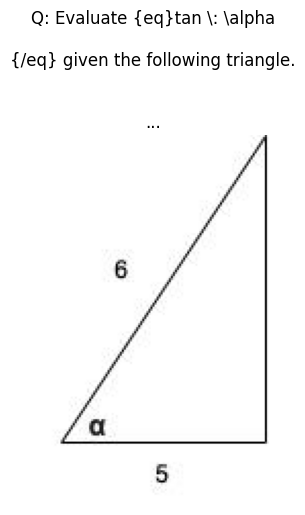

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


TRUE ANSWER: \( \frac{\sqrt{11}}{5} \)

✅ Qwen3.5-0.8b fine-tuned:
We are given a right-angled triangle with sides 6, 5, and hypotenuse $ c $. The angle $\alpha$ is at vertex A (the bottom-right corner), so we can use trigonometric definitions to find $\tan(\alpha)$.

---

### Step-by-step:

In any right triangle, if you have legs of length $a = 5$, $b = 6$, then the **hypotenuse** $c$ satisfies:

$$
c^2 = a^2 + b^2 = 5^2 + 6^2 = 25 + 36 = 61
\Rightarrow c = \sqrt{61}
$$

Now, consider the angles:

- At vertex A (bottom-right): this corresponds to side opposite to leg $a=5$, which is the hypotenuse $c=\sqrt{61}$ → adjacent side is leg $b=6$? Wait — let’s clarify labeling carefully.

Actually, standard convention for drawing triangles:

Let’s label vertices as follows:

- Let point B be top-left (right angle).
- Point C be bottom-right (angle α).
- Point D be left-bottom (opposite to angle α).

Then:

- Side BC = 6 (vertical leg)
- Side CD = 5 (horizontal leg)
→ So, adjacent side to ang

In [ ]:
def process_inference_text_only(question, tokenizer):
    messages = [
        {"role": "system", "content": "You are a helpful AI assistant. Put the final answer in <answer> and </answer> tags"},
        {"role": "user", "content": question}
    ]
    text_prompt = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = tokenizer(text_prompt, return_tensors="pt").to(lora_model.device)
    return inputs


def get_answer_text(model, inputs, tokenizer):
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
        )
    return tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)


def compare_answers_visual(idx=2):
    sample = test_ds[idx]
    question = sample["question"]
    true_answer = sample["short_answer"]

    plt.imshow(sample["image"])
    plt.axis("off")
    plt.title(f"Q: {question[:80]}...")
    plt.show()

    print(f"TRUE ANSWER: {true_answer}")
    print("="*60)

    # Our trained model
    inputs = process_inference(test_ds, processor, idx)
    our_answer = get_answer(lora_model, inputs)
    print(f"\n✅ Qwen3.5-0.8b fine-tuned:\n{our_answer}")
    del inputs
    torch.cuda.empty_cache()

    # 2. Qwen2.5-0.5B
    inp = process_inference_text_only(question, qwen_tokenizer)
    q_answer = get_answer_text(qwen, inp, qwen_tokenizer)
    print(f"\n❌ Qwen2.5-0.5B (no fine-tuning):\n{q_answer}")
    del inp
    torch.cuda.empty_cache()

    # 3. SmolLM2
    inp = process_inference_text_only(question, smol_tokenizer)
    s_answer = get_answer_text(smol, inp, smol_tokenizer)
    print(f"\n❌ SmolLM2-360M (no fine-tuning):\n{s_answer}")
    del inp
    torch.cuda.empty_cache()

compare_answers_visual(idx=2)

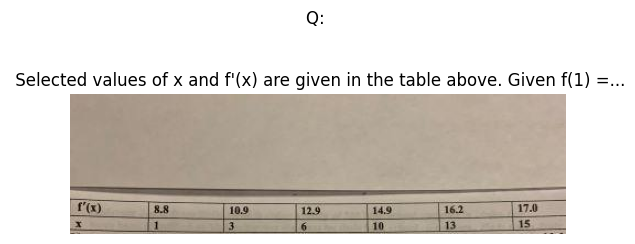

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


TRUE ANSWER: 199

✅ Qwen3.5-0.8b fine-tuned:
We are given:

- A table with points $(x_i, f(x_i))$ for $i = 1, 2, \dots, n$, where we need to find $f(15)$ using **trapezoidal rule** with **5 subintervals**.
- We’re told that selected values of $x$ and $f'(x)$ are provided — but since they’re not explicitly listed as input data (only part of the image), let’s assume standard finite difference or numerical integration context. However, looking at the problem again, it seems like this might be from a textbook example involving approximating integrals via trapezoids over discrete intervals.

But wait — actually, re-examining: The question says “Selected values of $x$ and $f'(x)$ are given”, yet only partial information is shown. This suggests either:

1. There was an original source diagram/table I don’t have access to fully, OR  
2. It’s implied that we should use the function form defined by some underlying formula.

However, another possibility: Perhaps these numbers come from a specific

In [ ]:
compare_answers_visual(idx=19)

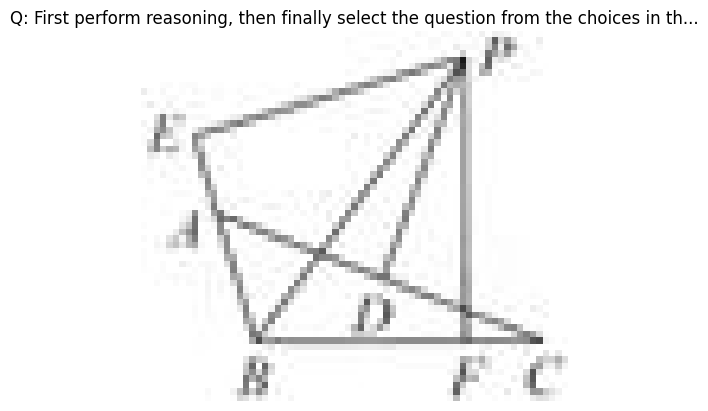

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


TRUE ANSWER: B

✅ Qwen3.5-0.8b fine-tuned:
To solve this problem, we’ll use geometric properties involving congruent triangles and symmetry.

---

### Step 1: Understand the configuration

We’re told that **BP** is the **angle bisector** of ∠ABC, so it divides ∠ABC into two equal angles:  
∠ABP = ∠CBP = (some value).

Also, **DP** is the **perpendicular bisector of segment AC**, meaning any line drawn from D on AC perpendicular to AC will also be symmetric with respect to AC — but more importantly, since DP ⊥ AC and passes through its midpoint M, points A and C lie on opposite sides of the perpendicular bisector, making △ADM ≅ △CDM by SAS or SSS if we consider lengths.

But here’s a key insight: because **DP is the perpendicular bisector of AC**, for every point X on one side of AC, there exists a corresponding point Y on the other such that XY = XC and DY = XD? Not exactly — better to think about reflection over line AC.

Actually, let's try a different approach using coordinate geome

In [ ]:
compare_answers_visual(idx=65)

In [ ]:
# Сохраняем LoRA веса
lora_model.save_pretrained("/content/qwen-finetuned")
processor.save_pretrained("/content/qwen-finetuned")

print("Model saved!")

import shutil
shutil.make_archive("/content/qwen-finetuned", 'zip', "/content/qwen-finetuned")

Model saved!


'/content/qwen-finetuned.zip'